In [5]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe

FUNCIONES AUXILIARES

In [6]:
# FUNCIONES AUXILIARES
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')

    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')

    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()

2. CARGA Y LIMPIEZA DE DATOS


In [7]:
# Carga inicial y diagnóstico general
df_csv = pd.read_csv("datasets/player_stats.csv")
print("Cantidad de filas y columnas =", df_csv.shape)
df_csv.info()

# Diagnóstico de datos nulos
nulos = df_csv.isnull().sum()
porcentaje_nulos = (nulos / len(df_csv)) * 100
tabla_nulos = pd.DataFrame({'cantidad de nulos': nulos, 'Porcentaje': porcentaje_nulos})
print(tabla_nulos)

# Eliminación de columnas vacías e imputación de métricas de arqueros
columnas_vacias = ['shots', 'shots_on_target', 'average_rating']
df_csv.drop(columns=columnas_vacias, inplace=True, errors='ignore')

columna_arquero = ['clean_sheets', 'saves', 'goals_conceded']
df_csv[columna_arquero] = df_csv[columna_arquero].fillna(0)

if 'data_source' in df_csv.columns:
    df_csv['data_source'] = df_csv['data_source'].fillna('Sin especificar')

print('Cantidad de nulos tras limpieza:', df_csv.isnull().sum().sum())
print("Cantidad de filas duplicadas:", df_csv.duplicated().sum())

Cantidad de filas y columnas = (1248, 21)
<class 'pandas.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   player_id        1248 non-null   int64  
 1   player_name      1248 non-null   str    
 2   team_id          1248 non-null   int64  
 3   position         1248 non-null   str    
 4   matches_played   1248 non-null   int64  
 5   matches_started  1248 non-null   int64  
 6   minutes_played   1248 non-null   int64  
 7   goals            1248 non-null   int64  
 8   assists          1248 non-null   int64  
 9   shots            0 non-null      float64
 10  shots_on_target  0 non-null      float64
 11  yellow_cards     1248 non-null   int64  
 12  red_cards        1248 non-null   int64  
 13  penalty_goals    1248 non-null   int64  
 14  own_goals        1248 non-null   int64  
 15  clean_sheets     145 non-null    float64
 16  saves            145 non-null

3. ANALISIS DE DATOS

In [8]:
# Corrección de tipos de datos para prevenir cálculos erróneos en correlaciones
df_csv['player_id'] = df_csv['player_id'].astype(str)
df_csv['team_id'] = df_csv['team_id'].astype(str)
df_csv['position'] = df_csv['position'].astype('category')

# Creación de métrica absoluta
df_csv['contribuciones_gol'] = df_csv['goals'] + df_csv['assists']

# Filtro estadístico: Muestra representativa (>= 90 minutos)
MIN_MINUTOS = 90
df_active = df_csv[df_csv['minutes_played'] >= MIN_MINUTOS].copy()

# Normalización de métricas P90
df_active['goals_per_90'] = (df_active['goals'] / df_active['minutes_played']) * 90
df_active['assists_per_90'] = (df_active['assists'] / df_active['minutes_played']) * 90
df_active['contrib_per_90'] = (df_active['contribuciones_gol'] / df_active['minutes_played']) * 90

cols_p90 = ['goals_per_90', 'assists_per_90', 'contrib_per_90']
df_active[cols_p90] = df_active[cols_p90].round(2)

print(f"Total plantilla: {len(df_csv)} | Jugadores activos (>=90 min): {len(df_active)}\n")

# Validación de caso atípico (Arqueros con gol/asistencia)
gk_con_goles = df_active[(df_active['position'] == 'GK') & (df_active['contribuciones_gol'] > 0)]
print(f"Cantidad de arqueros con aportes ofensivos: {len(gk_con_goles)}")
if not gk_con_goles.empty:
    print(gk_con_goles[['player_name', 'minutes_played', 'goals', 'assists', 'contrib_per_90']], "\n")

# Segmentación por rol táctico
df_field = df_active[df_active['position'] != 'GK'].copy()
df_gk = df_active[df_active['position'] == 'GK'].copy()

Total plantilla: 1248 | Jugadores activos (>=90 min): 767

Cantidad de arqueros con aportes ofensivos: 1
                  player_name  minutes_played  goals  assists  contrib_per_90
624  Thibaut Nicolas Courtois             570      0        1            0.16 



- Aca la idea es eliminar a los jugadores con menos de 90 minutos, para evitar promedios engañosos.
Alguien que entra que juega 5 minutos y hace un gol daria un valor irreal de 18 goles por partido.

- Se realiza una validación de los puestos , mas que nada para saber si hay algun arquero que tenga asistencias o goles
debido a que es muy poco comun.

- Se hace una division de posiciones entre jugadores de campo y arqueros , asi puedo sacar las estadisticas como atajadas.

4. ESTADISTICA

NOTAR:
 Media = 0.21 
 Mediana = 0 
 Mas del 50% de los jugadores no suman goles ni asistencia , el promedio sube a 0,21 porque un grupo reducido de delanteros tiene cifras muy altas.

 - Los arqueros tienen mas minutos jugados que los jugadores de campo
    301 min vs 258 min  

=== RESUMEN ESTADÍSTICO P90 (JUGADORES DE CAMPO) ===


,minutes_played,goals,assists,contrib_per_90
count,703.00,703.00,703.00,703.00
mean,258.43,0.40,0.27,0.21
std,120.22,0.98,0.69,0.38
min,90.00,0.00,0.00,0.00
25%,166.00,0.00,0.00,0.00
50%,252.00,0.00,0.00,0.00
75%,336.00,0.00,0.00,0.32
max,750.00,10.00,8.00,3.02


=== RESUMEN ESTADÍSTICO (ARQUEROS) ===


,minutes_played,saves,clean_sheets,goals_conceded
count,64.00,64.00,64.00,64.00
mean,301.44,10.81,0.86,4.91
std,140.99,5.96,1.11,2.38
min,90.00,0.00,0.00,0.00
25%,180.00,7.00,0.00,3.00
50%,270.00,9.00,0.00,5.00
75%,390.00,14.25,2.00,6.25
max,630.00,29.00,5.00,10.00


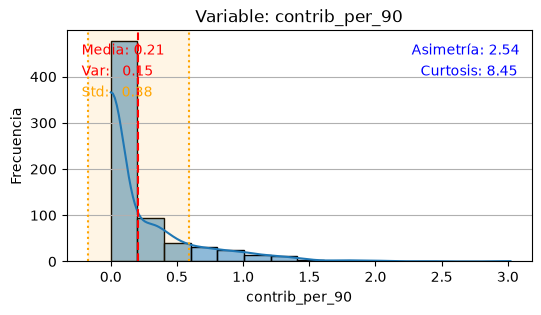

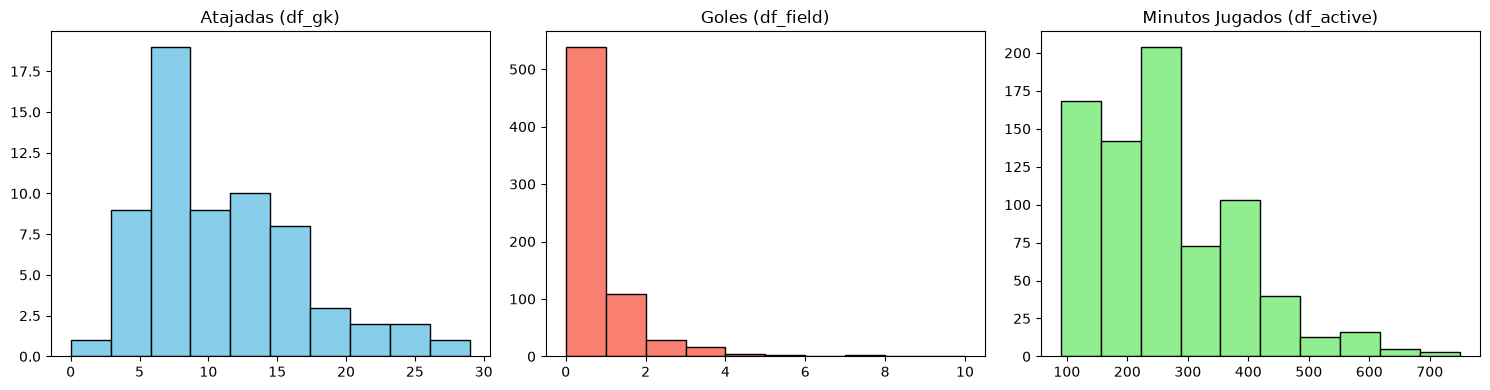

In [12]:
# Resumen numérico de métricas de campo (df_field)
print("=== RESUMEN ESTADÍSTICO P90 (JUGADORES DE CAMPO) ===")
display(df_field[['minutes_played', 'goals', 'assists', 'contrib_per_90']].describe().round(2))

# Resumen numérico de métricas de portería (df_gk)
print("=== RESUMEN ESTADÍSTICO (ARQUEROS) ===")
display(df_gk[['minutes_played', 'saves', 'clean_sheets', 'goals_conceded']].describe().round(2))

# Histograma principal de contribuciones P90
plot_histograma(df_field, 'contrib_per_90', mvd=True, snk=True, bins=15)

# Distribuciones univariadas individuales
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(df_gk['saves'], bins=10, color='skyblue', edgecolor='black')
ax[0].set_title("Atajadas (df_gk)")

ax[1].hist(df_field['goals'], bins=10, color='salmon', edgecolor='black')
ax[1].set_title('Goles (df_field)')

ax[2].hist(df_active['minutes_played'], bins=10, color='lightgreen', edgecolor='black')
ax[2].set_title('Minutos Jugados (df_active)')
plt.tight_layout()
plt.show()

Analisis de media y mediana 


5. Analisis univariado categorico

--- Distribución Categórica: Posiciones (Jugadores Activos >= 90 min) ---


,Cantidad de Jugadores,Porcentaje del Total (%)
position,,
DEF,284,37.03
MID,246,32.07
FWD,173,22.56
GK,64,8.34


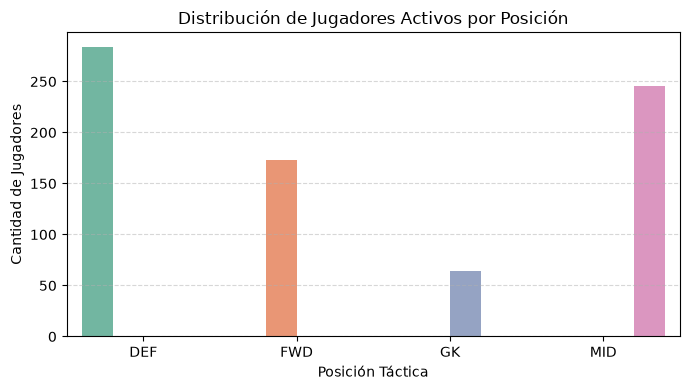

In [10]:
# Distribución por posición táctica sobre el plantel activo (incluye GK)
conteo = df_active['position'].value_counts()
porcentaje = df_active['position'].value_counts(normalize=True).mul(100).round(2)

tabla_posiciones = pd.DataFrame({
    'Cantidad de Jugadores': conteo,
    'Porcentaje del Total (%)': porcentaje
})

print("--- Distribución Categórica: Posiciones (Jugadores Activos >= 90 min) ---")
display(tabla_posiciones)

# Gráfico de conteo por categoría
plt.figure(figsize=(7, 4))
sns.countplot(data=df_active, x='position', palette='Set2', hue='position', legend=False)
plt.title('Distribución de Jugadores Activos por Posición')
plt.xlabel('Posición Táctica')
plt.ylabel('Cantidad de Jugadores')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

6. Relacion entre variables

/tmp/ipykernel_14344/3148128829.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_efectivos, x='contrib_per_90', y='player_name', palette='Blues_r')


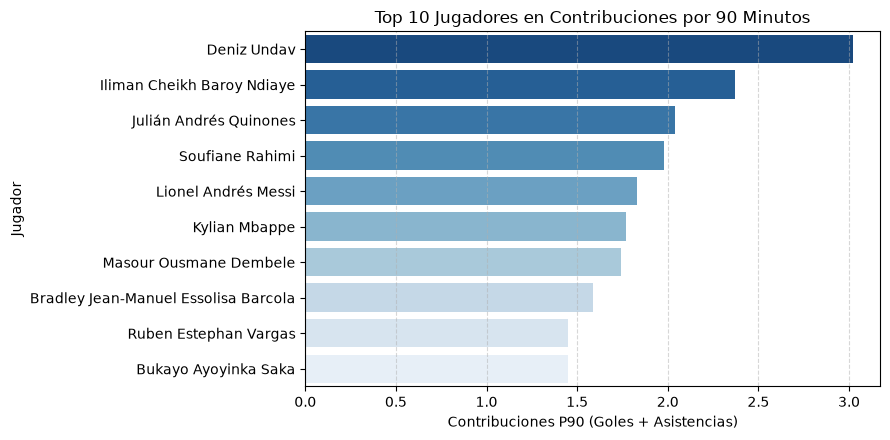

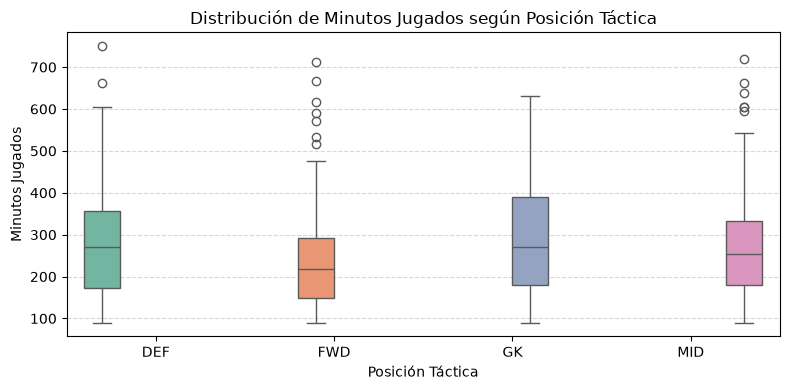

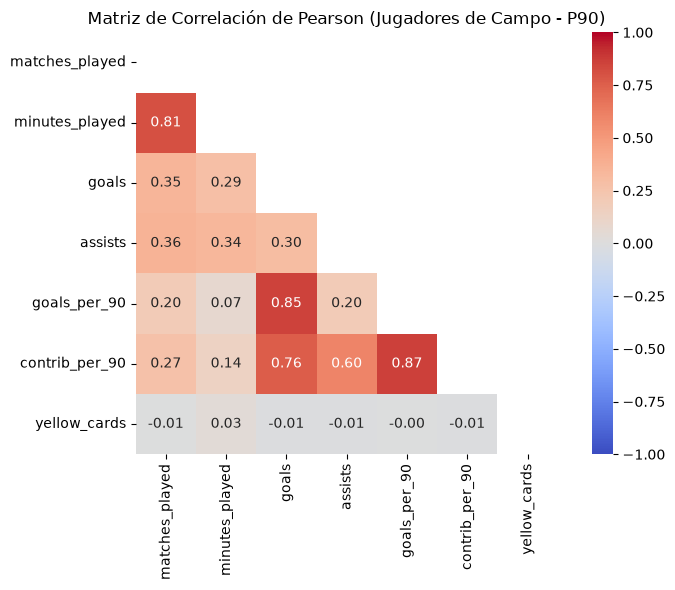

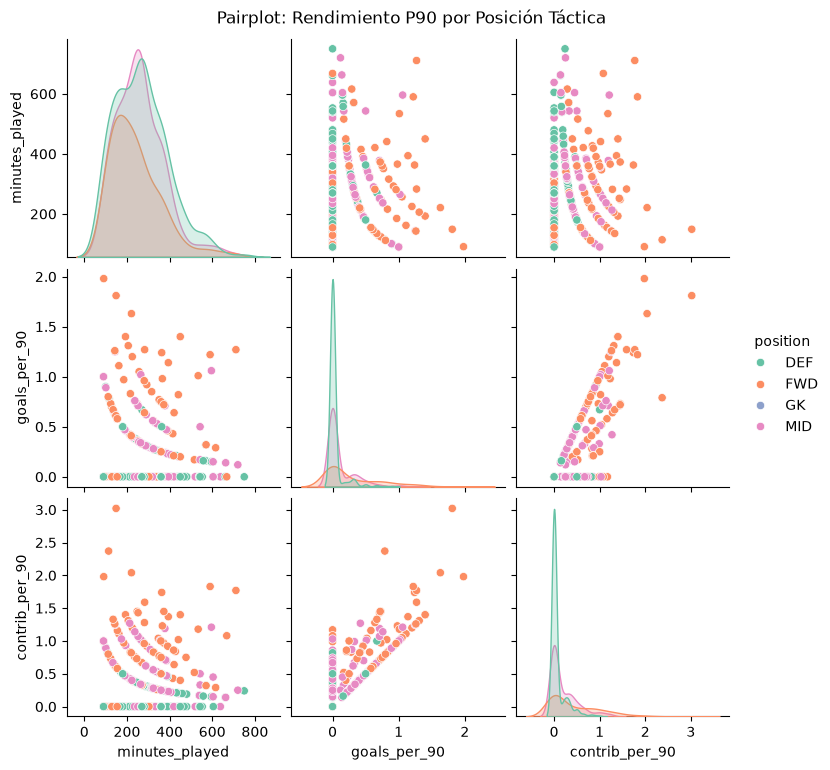

In [11]:
# 1. Ranking de impacto (Top 10 P90 - Jugadores de campo)
top_efectivos = df_field.sort_values(by='contrib_per_90', ascending=False).head(10)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=top_efectivos, x='contrib_per_90', y='player_name', palette='Blues_r')
plt.title('Top 10 Jugadores en Contribuciones por 90 Minutos')
plt.xlabel('Contribuciones P90 (Goles + Asistencias)')
plt.ylabel('Jugador')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Minutos jugados por Posición (Global - Incluye GK)
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_active, x='position', y='minutes_played', palette='Set2', hue='position', legend=False)
plt.title('Distribución de Minutos Jugados según Posición Táctica')
plt.xlabel('Posición Táctica')
plt.ylabel('Minutos Jugados')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. Matriz de Correlación de Pearson P90 (Jugadores de Campo)
cols_num_campo = ['matches_played', 'minutes_played', 'goals', 'assists', 'goals_per_90', 'contrib_per_90', 'yellow_cards']
corr_matrix = df_field[cols_num_campo].corr()
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, mask=mascara)
plt.title('Matriz de Correlación de Pearson (Jugadores de Campo - P90)')
plt.tight_layout()
plt.show()

# 4. Pairplot Multivariado P90
grafico = sns.pairplot(data=df_field, vars=['minutes_played', 'goals_per_90', 'contrib_per_90'], hue='position', palette='Set2')
grafico.figure.suptitle('Pairplot: Rendimiento P90 por Posición Táctica', y=1.02)
plt.show()